## ATTENTION

#### BELOW SHELL SHOULD ONLY RUN ONCE TO CREATE THE MERGED DATASET !! 
#### AND THAT ONLY IF IT IS NOT CREATED YET !!!

In [ ]:
from pathlib import Path
import shutil
from itertools import islice

DATA_ROOT = Path.home() / "BLUEBERRY_DATA"
DATASETS_ROOT = DATA_ROOT / "datasets"

MERGED_ROOT = DATA_ROOT / "MERGED"
(MERGED_ROOT / "images").mkdir(parents=True, exist_ok=True)
(MERGED_ROOT / "labels").mkdir(parents=True, exist_ok=True)

GLOBAL_CLASS_DICT = {"bud":0, "buds":0, "Bud":0, 
                     "flower":1, "Flower":1,
                     "green":2, "Green":2, 
                     "pink":3, 
                     "purple":4,
                     "blue":5}

# for dataset in islice(DATA_ROOT.iterdir(), 5, 6):
# for dataset in DATA_ROOT.iterdir():
for dataset in DATASETS_ROOT.iterdir():
  # ignore MERGED folder
  # if dataset.name == "MERGED" or "CLASSIFICATION":# or dataset.name == "dataset-c967718b":
  #   continue
  obj_names_path = dataset /"annotations/obj.names"
  # print(obj_names_path)
  local_cls_names = obj_names_path.open(encoding='utf-8').read().splitlines()
  for cls_name in local_cls_names:
    if cls_name not in GLOBAL_CLASS_DICT.keys():
      raise ValueError(f"class {cls_name} not in GLOBAL classes")
  if dataset.name == "dataset-c967718b": # UUID: c967718b-2031-49ca-aa14-080210cc3fc6
    # se auto to dataset ta .txt exoun 0, 2, 3, 4 indexes. Auto giati ipirxe bud (1) alla egine delete.
    # ara thelw [flower, green, pink, blue] na exoun local_idx 0, 2, 3, 4
    local_class_idx_to_global_map = {i: GLOBAL_CLASS_DICT[cls_name] for i, cls_name in zip([0,2,3,4], local_cls_names)}
    print(f"Local class names: {local_cls_names} mapped with: {local_class_idx_to_global_map}")
  else:
    local_class_idx_to_global_map = {i: GLOBAL_CLASS_DICT[cls_name] for i, cls_name in enumerate(local_cls_names)}
    print(f"Local class names: {local_cls_names} mapped with: {local_class_idx_to_global_map}")

  labels_dir = dataset / "annotations/obj_train_data"
  images_dir = dataset / "images"
  if not labels_dir.exists():
    raise ValueError(f"{labels_dir} not found")

  # ** If i iterate only on the label files, so I ignore all the images with no annotation file. These are not background in most cases**
  # ** check debug below **
  for label_file in labels_dir.iterdir():
    new_lines = []

    with label_file.open(encoding = 'utf-8') as f:
      for line in f:
        parts = line.strip().split()
        local_cls_idx = int(parts[0])
        global_cls_idx = local_class_idx_to_global_map[local_cls_idx]
        parts[0] = str(global_cls_idx)
        new_lines.append(" ".join(parts))
        # print(f"{label_file.name} cls_idx {local_cls_idx} changed to {global_cls_idx}")

      # print(f"{label_file.name}, new_lines: {new_lines}")

    # write new label file
    out_label_path = MERGED_ROOT / "labels" / label_file.name
    out_label_path.write_text("\n".join(new_lines))

    # copy corresponding image
    img_name = label_file.with_suffix(".png").name
    src_img = images_dir / img_name
    dst_img = MERGED_ROOT / "images" / img_name
    # print(img_name)
    # print(src_img)
    # print(dst_img)

    if src_img.exists():
      shutil.copy(src_img ,dst_img)
      pass
    else:
      raise ValueError(f"{src_img} does not exist")

  print("===============================================================")


# OUTPUT_ROOT = 

# dataset = DATA_ROOT / "20260321@1150-Zeganis"
# labels_dir = dataset / "annotations/obj_train_data"
# for label_file in islice(labels_dir.iterdir(), 1):
#   new_lines = []
#   local_class_idx_to_global_map = {i: GLOBAL_CLASS_DICT[cls_name] for i, cls_name in enumerate(["bud", "flower"])}
# 
#   with label_file.open(encoding='utf-8') as f:
#     for line in f:
#       parts = line.strip().split()
#       local_cls_idx  = int(parts[0])
#       # print(local_cls_idx)
#       global_cls_idx = local_class_idx_to_global_map[local_cls_idx]
#       parts[0] = str(global_cls_idx) 
#       new_lines.append(" ".join(parts))
#     print("new_lines:", new_lines)
#     print(label_file.name)

Local class names: ['Bud'] mapped with: {0: 0}
Local class names: ['bud'] mapped with: {0: 0}
Local class names: ['buds'] mapped with: {0: 0}
Local class names: ['flower', 'green', 'pink', 'blue'] mapped with: {0: 1, 2: 2, 3: 3, 4: 5}
Local class names: ['flower', 'green', 'pink', 'blue'] mapped with: {0: 1, 1: 2, 2: 3, 3: 5}
Local class names: ['Flower', 'Bud', 'Green'] mapped with: {0: 1, 1: 0, 2: 2}
Local class names: ['flower', 'bud', 'green'] mapped with: {0: 1, 1: 0, 2: 2}
Local class names: ['flower', 'bud', 'green'] mapped with: {0: 1, 1: 0, 2: 2}
Local class names: ['Green', 'Bud', 'Flower'] mapped with: {0: 2, 1: 0, 2: 1}
Local class names: ['flower', 'bud', 'green'] mapped with: {0: 1, 1: 0, 2: 2}
Local class names: ['flower', 'bud', 'green'] mapped with: {0: 1, 1: 0, 2: 2}
Local class names: ['flower', 'bud', 'green', 'purple'] mapped with: {0: 1, 1: 0, 2: 2, 3: 4}
Local class names: ['flower', 'bud', 'green'] mapped with: {0: 1, 1: 0, 2: 2}
Local class names: ['Flower', 'B

### DEBUGGING BACKGROUND / NOT ANNOTATED 

In [ ]:
from pathlib import Path
from itertools import islice
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_ROOT = Path.home() / "BLUEBERRY_DATA"

MERGED_ROOT = DATA_ROOT / "MERGED"
(MERGED_ROOT / "images").mkdir(parents=True, exist_ok=True)
(MERGED_ROOT / "labels").mkdir(parents=True, exist_ok=True)

GLOBAL_CLASS_DICT = {"bud":0, "buds":0, "Bud":0, 
                     "flower":1, "Flower":1,
                     "green":2, "Green":2, 
                     "pink":3, 
                     "purple":4,
                     "blue":5}

MISSING_LABEL_IMAGES_PER_DATASET = defaultdict(list)

# for dataset in islice(DATA_ROOT.iterdir(), 5, 6):
for dataset in DATA_ROOT.iterdir():
  MISSING_LABEL_COUNTER = 0 # how many images have no corresponding label file
  EMPTY_LABEL_COUNTER = 0
  # ignore MERGED folder
  if dataset.name == "MERGED":
    continue
  obj_names_path = dataset /"annotations/obj.names"
  # print(obj_names_path)
  local_cls_names = obj_names_path.open(encoding='utf-8').read().splitlines()
  for cls_name in local_cls_names:
    if cls_name not in GLOBAL_CLASS_DICT.keys():
      raise ValueError(f"class {cls_name} not in GLOBAL classes")
  local_class_idx_to_global_map = {i: GLOBAL_CLASS_DICT[cls_name] for i, cls_name in enumerate(local_cls_names)}
  # print(f"Local class names: {local_cls_names} mapped with: {local_class_idx_to_global_map}")

  labels_dir = dataset / "annotations/obj_train_data"
  images_dir = dataset / "images"
  if not labels_dir.exists():
    raise ValueError(f"{labels_dir} not found")

  # ** If i iterate only on the label files, then I have no background images in my dataset..  **
  # ** SO THIS PARSING IS WRONG !! **
  # for label_file in labels_dir.iterdir():
  for img_file in images_dir.iterdir():
    # print(img_file)
    label_name = img_file.with_suffix(".txt").name
    label_file = labels_dir / label_name
    # print(label_file)

    if not label_file.exists():
      # print(f"Image without label : {dataset.name } / {img_file.name}")
      MISSING_LABEL_COUNTER += 1
      possible_background_img = cv2.imread(img_file)
      MISSING_LABEL_IMAGES_PER_DATASET[dataset.name].append(cv2.cvtColor(possible_background_img, cv2.COLOR_BGR2RGB))

    else:
      # count empty label files
      if label_file.stat().st_size == 0:
        EMPTY_LABEL_COUNTER += 1

  print(f"Dataset : {dataset.name:<50s} | missing labels: {MISSING_LABEL_COUNTER:>3} | empty labels: {EMPTY_LABEL_COUNTER}")
  print("================================================================================")

Dataset : 20260102@1649-Hortitool-ChãsdeTavares              | missing labels:   0 | empty labels: 53
Dataset : 20260220@1654-Hortitool-ChãsdeTavares              | missing labels:   0 | empty labels: 84
Dataset : 20260219@1411-Hortitool-ChãsdeTavares              | missing labels:   0 | empty labels: 102
Dataset : dataset-c967718b                                   | missing labels:  10 | empty labels: 95
Dataset : dataset-c834a7b7                                   | missing labels: 144 | empty labels: 78
Dataset : 20260313@0836-Hortitool-ChãsdeTavares              | missing labels:   0 | empty labels: 113
Dataset : 20260317@1016-Hortifrut-Almonte                    | missing labels:   0 | empty labels: 68
Dataset : 20260409@0959-Hortitool-ChãsdeTavares              | missing labels: 266 | empty labels: 7
Dataset : 20251128@1352-AgroBlu-SantoPadredellePerriere      | missing labels:   0 | empty labels: 9
Dataset : 20260416@1432-Zeganis-Gulukheti                    | missing labels:   0

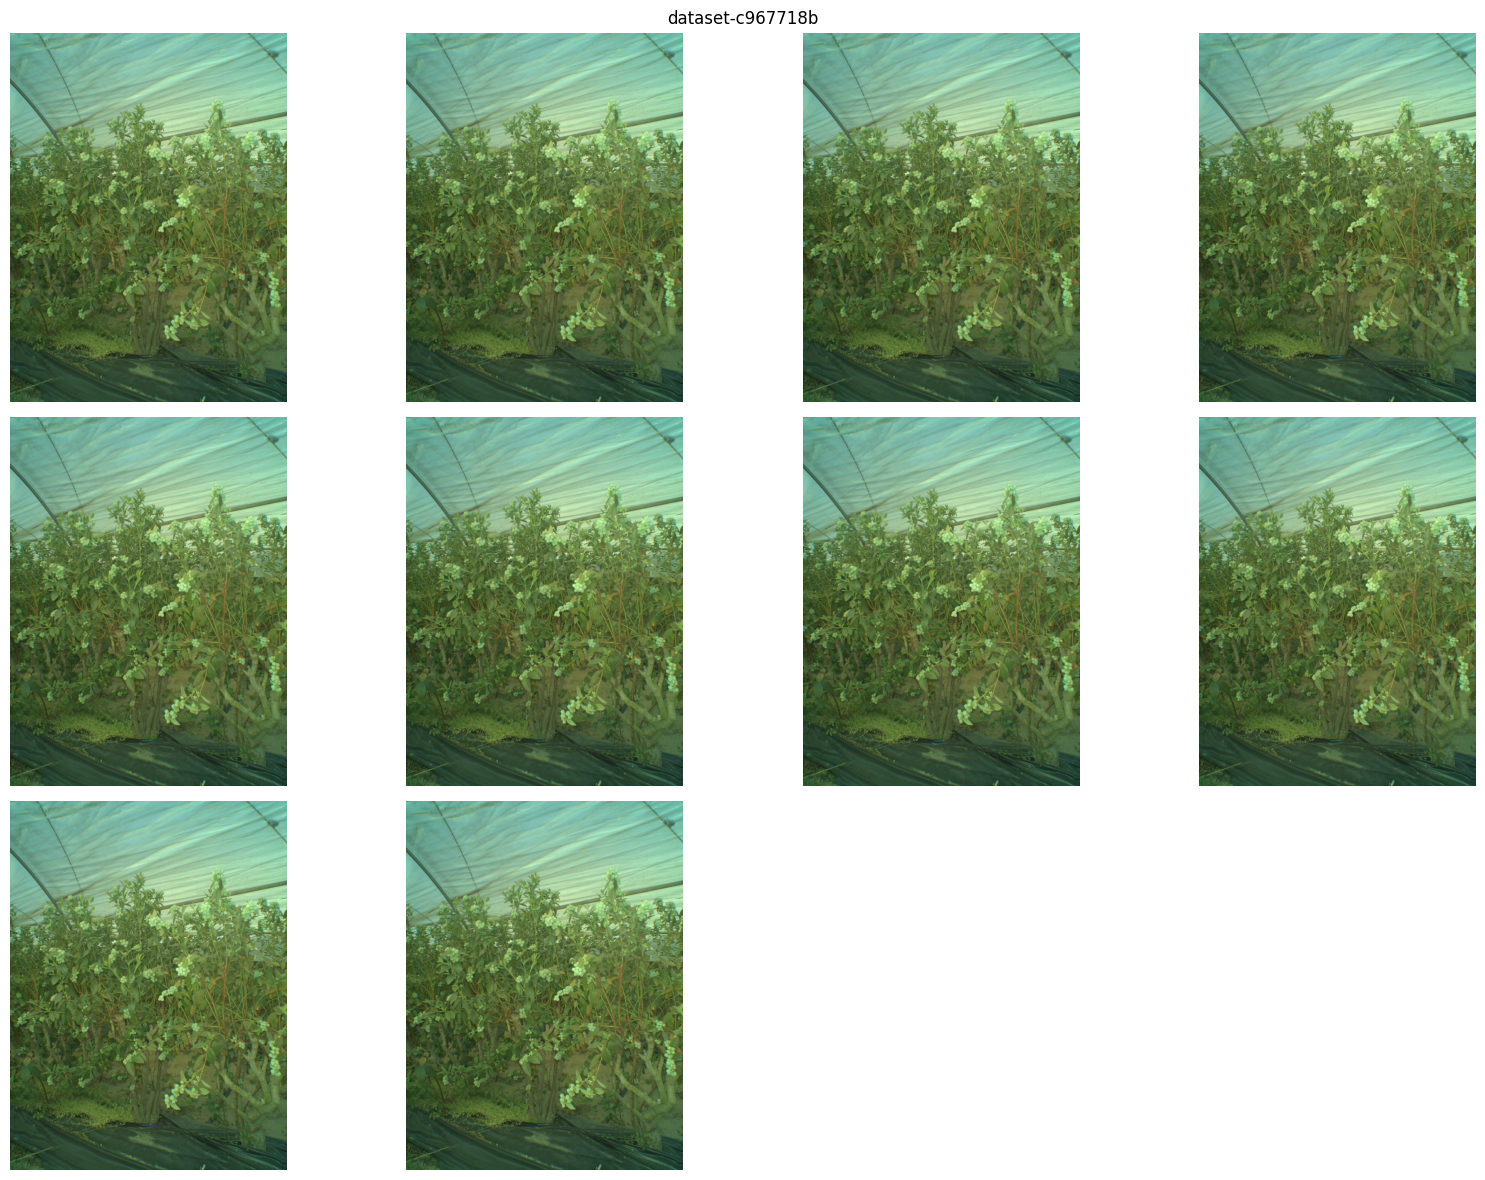

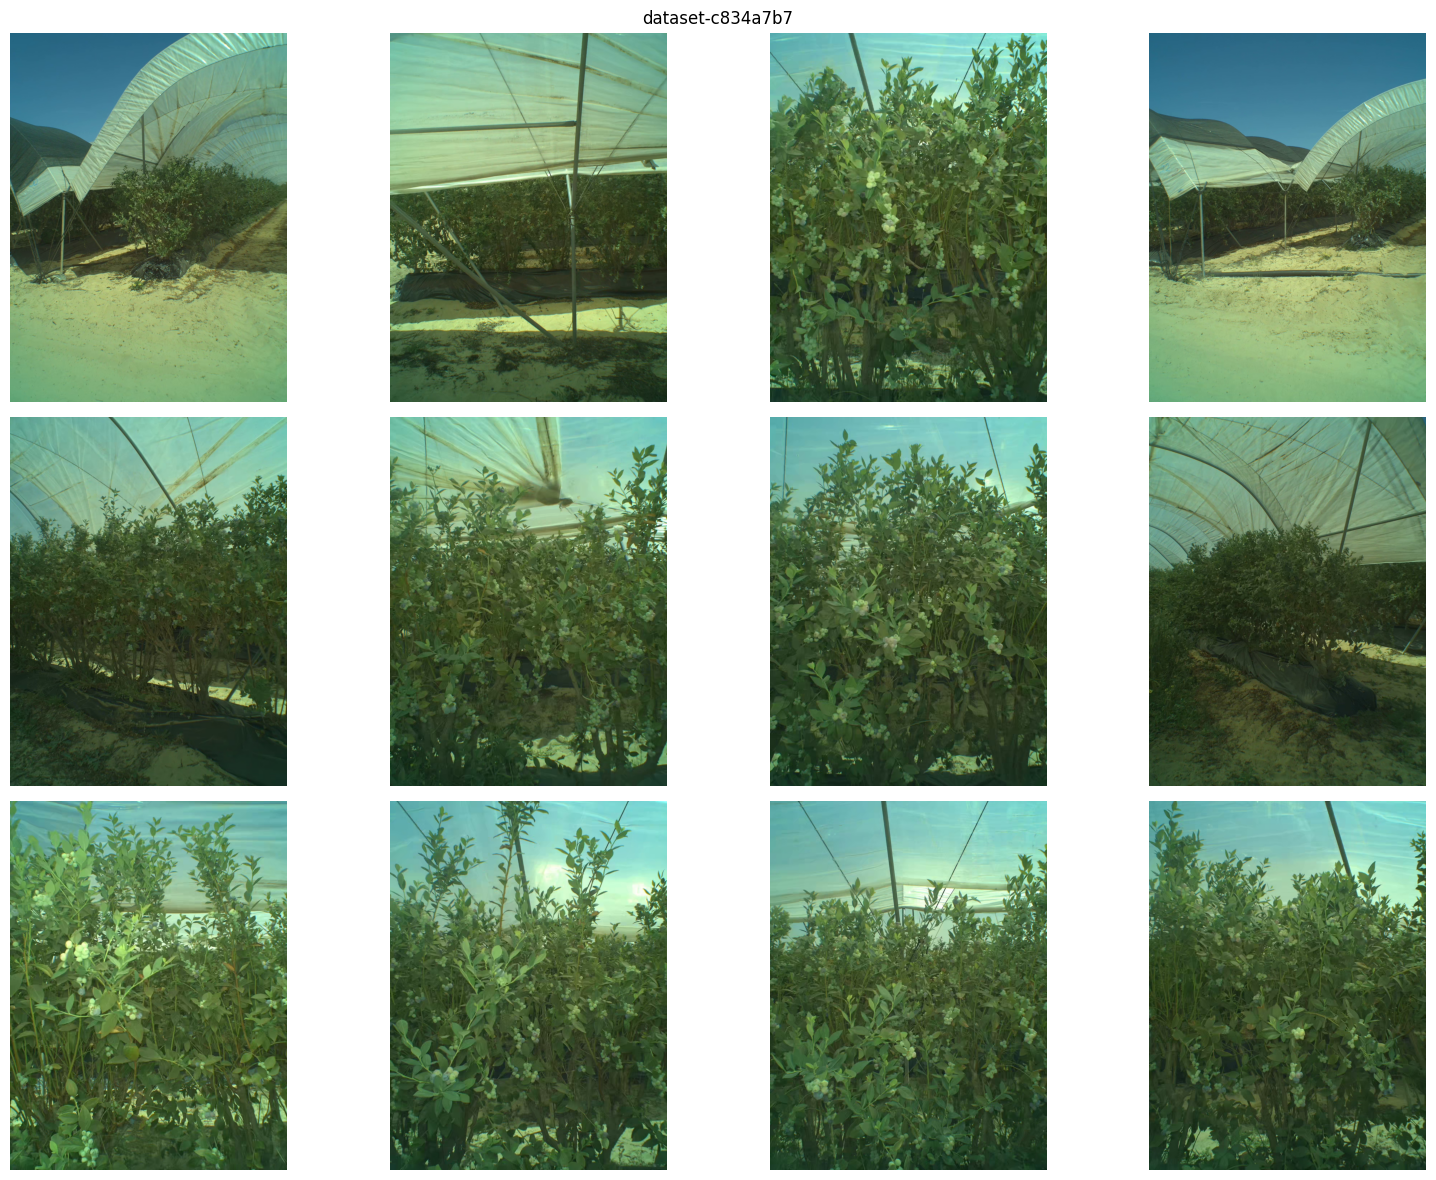

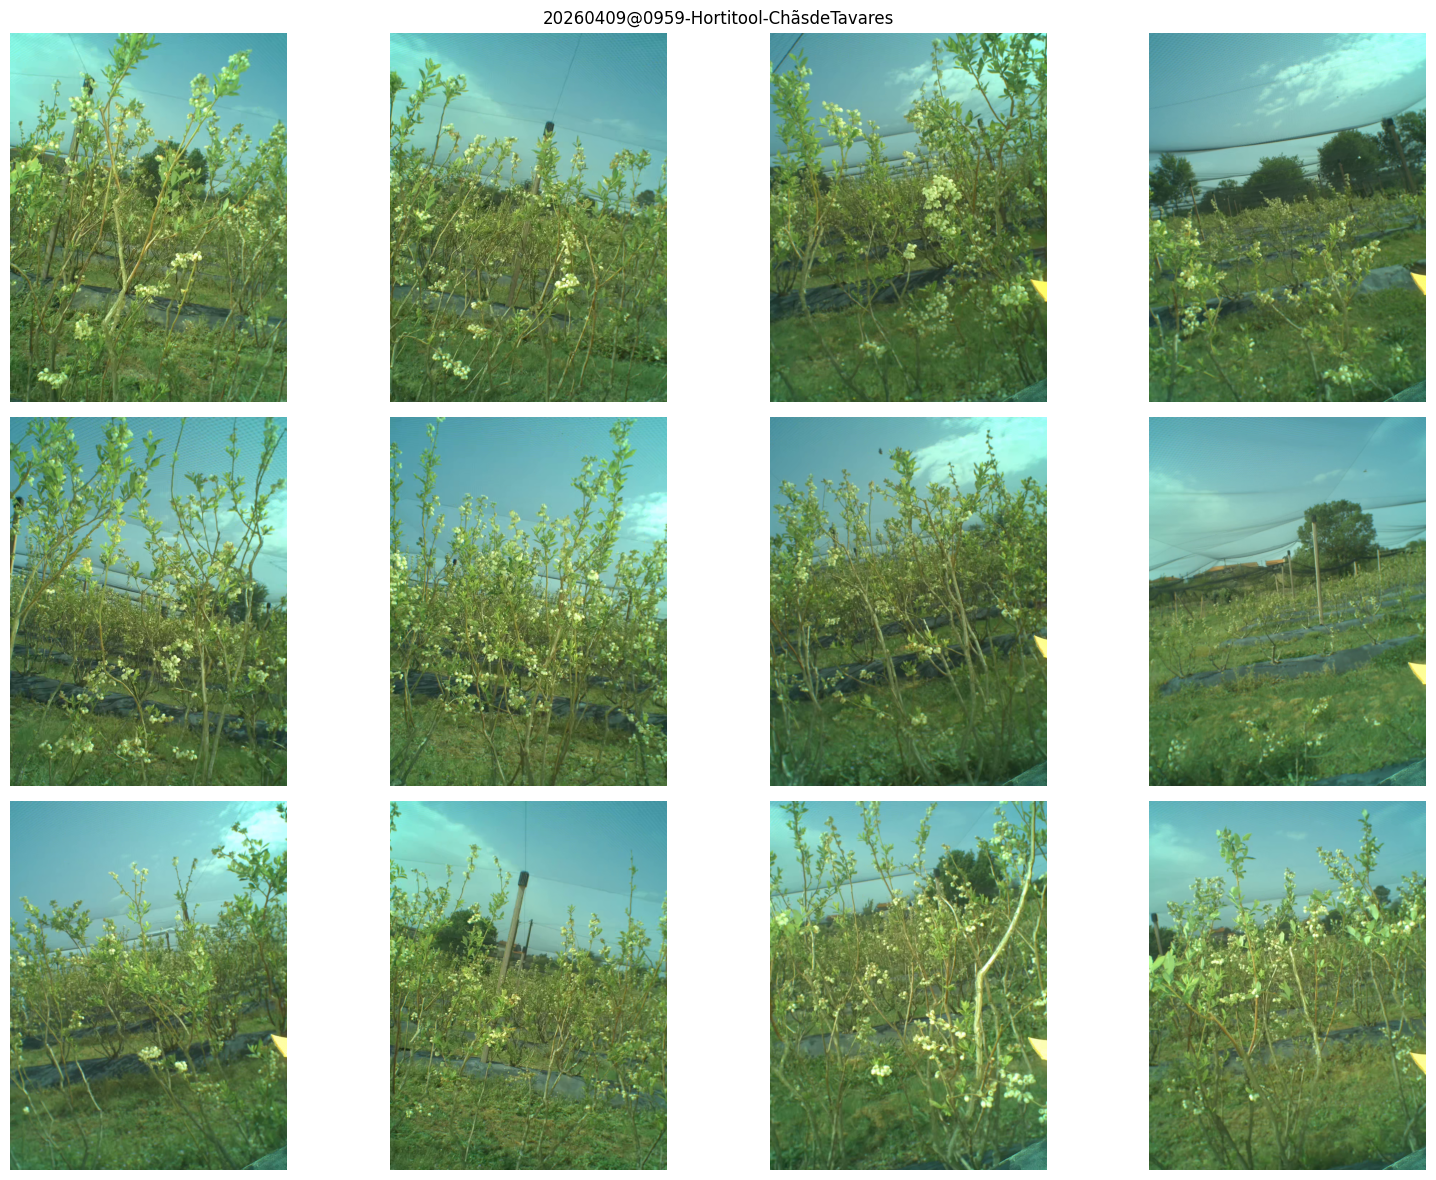

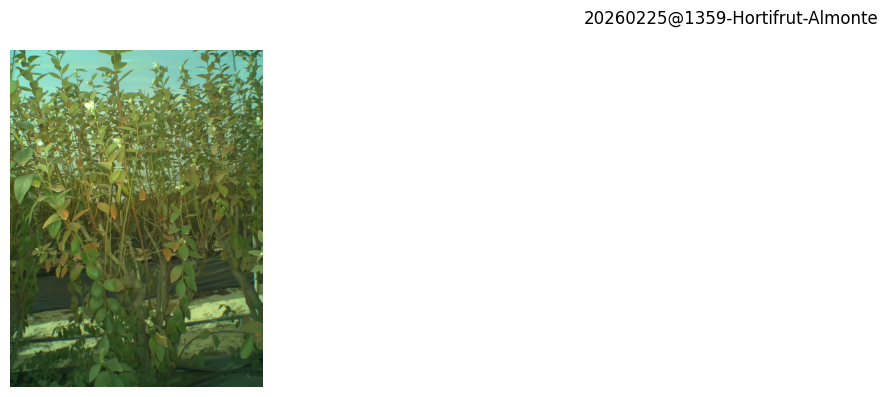

In [37]:
import random

random.seed(123456789)
def inspect_dataset(dataset_name, unlabeled_dict, n=12):
    images = unlabeled_dict.get(dataset_name, [])
    sample = random.sample(images, min(n, len(images)))

    cols = 4
    rows = (len(sample) + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, img in enumerate(sample):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        # plt.title(img_path.name)
        plt.axis("off")

    plt.suptitle(dataset_name)
    plt.tight_layout()
    plt.show()

for dataset in MISSING_LABEL_IMAGES_PER_DATASET.keys():
    inspect_dataset(dataset, MISSING_LABEL_IMAGES_PER_DATASET)

### CONCLUSION

Because I see that in many cases no label file corresponds to not-annotated image, but which contains fruits, I will not use these images at all (as background). 

I will keep the initial loop, parsing the labels, and keeping only the images with a corresponding label..

### CREATE IMAGE CLASSIFICATION DATASET CROPPING BBOXEs

In [ ]:
from pathlib import Path
from itertools import islice
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict
from dataclasses import dataclass
from torchvision.io import decode_image

@dataclass
class BBox:
  cls: int # index
  # cls_name: str
  xc: float # normalized
  yc: float
  w: float
  h: float

  def to_xyxy(self, img_h, img_w) -> tuple[int, int, int, int]:
    x1 = (self.xc - self.w/2) * img_w # x_min
    y1 = (self.yc - self.h/2) * img_h # y_min
    x2 = (self.xc + self.w/2) * img_w # x_max
    y2 = (self.yc + self.h/2) * img_h # y_max
    return int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))

  def to_xyxy_expanded(self, scale:float, img_h, img_w) -> tuple[int, int, int, int]:
    '''
    TODO: add min_size: only keep bboxes with at least that size, e.g. 32 pixels
    '''
    pass

BLUEBERRY_ROOT = Path.home() / "BLUEBERRY_DATA"
MERGED_ROOT = BLUEBERRY_ROOT / "MERGED"
LABELS_ROOT =  MERGED_ROOT / "labels"
IMAGES_ROOT =  MERGED_ROOT / "images"

CLASSIFICATION_ROOT =  BLUEBERRY_ROOT / "CLASSIFICATION"

# for label_file in islice(LABELS_ROOT.iterdir(), 2):
for label_file in LABELS_ROOT.iterdir():
  img_name = label_file.with_suffix(".png").name 
  # print(img_name, label_file.stem)
  img_path = IMAGES_ROOT / img_name
  # assert img_path.exists()
  img = cv2.imread(img_path)
  img_h, img_w, _ = img.shape
  with label_file.open() as f:
    for i, line in enumerate(f):
      cls, cx, cy, w, h = map(float, line.split())
      cls = int(cls)
      bbox = BBox(cls,cx,cy,w,h)
      x1, y1, x2, y2 = bbox.to_xyxy(img_h, img_w)

      crop = img[y1:y2, x1:x2]
      # path to write the bbox for classification
      dst_box_path = CLASSIFICATION_ROOT / f"{str(cls) + '/' + img_path.stem}_{i}.png"
      # print(dst_box_path)
      cv2.imwrite(dst_box_path, crop)



In [37]:
from pathlib import Path
import shutil
from itertools import islice

DATA_ROOT = Path.home() / "BLUEBERRY_DATA"

MERGED_ROOT = DATA_ROOT / "MERGED"
(MERGED_ROOT / "images").mkdir(parents=True, exist_ok=True)
(MERGED_ROOT / "labels").mkdir(parents=True, exist_ok=True)

GLOBAL_CLASS_DICT = {"bud":0, "buds":0, "Bud":0, 
                     "flower":1, "Flower":1,
                     "green":2, "Green":2, 
                     "pink":3, 
                     "purple":4,
                     "blue":5}


# for dataset in islice(DATA_ROOT.iterdir(), 5, 6):
for dataset in DATA_ROOT.iterdir():
  # ignore MERGED folder
  if not dataset.name == "dataset-c967718b":
    continue
  obj_names_path = dataset /"annotations/obj.names"
  # print(obj_names_path)
  local_cls_names = obj_names_path.open(encoding='utf-8').read().splitlines()
  for cls_name in local_cls_names:
    if cls_name not in GLOBAL_CLASS_DICT.keys():
      raise ValueError(f"class {cls_name} not in GLOBAL classes")

  # se auto to dataset ta txt exoun 0, 2, 3, 4. Auto giati ipirxe bud (1) alla egine delete.
  # ara thelw [flower, green, pink, blue] na exoun local_idx 0, 2, 3, 4
  local_class_idx_to_global_map = {i: GLOBAL_CLASS_DICT[cls_name] for i, cls_name in zip([0,2,3,4], local_cls_names)}
  print(f"Local class names: {local_cls_names} mapped with: {local_class_idx_to_global_map}")

  labels_dir = dataset / "annotations/obj_train_data"
  images_dir = dataset / "images"
  if not labels_dir.exists():
    raise ValueError(f"{labels_dir} not found")

  # ** If i iterate only on the label files, so I ignore all the images with no annotation file. These are not background in most cases**
  # ** check debug below **
  for label_file in labels_dir.iterdir():
    new_lines = []

    with label_file.open(encoding = 'utf-8') as f:
      for line in f:
        parts = line.strip().split()
        local_cls_idx = int(parts[0])
        if local_cls_idx == 1:
          print("1 Found")
        # global_cls_idx = local_class_idx_to_global_map[local_cls_idx]
        parts[0] = str(global_cls_idx)
        new_lines.append(" ".join(parts))
        # print(f"{label_file.name} cls_idx {local_cls_idx} changed to {global_cls_idx}")


Local class names: ['flower', 'green', 'pink', 'blue'] mapped with: {0: 1, 2: 2, 3: 3, 4: 5}
